In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
from packaging.version import Version

assert Version(torch.__version__) >= Version("2.6.0")

In [ ]:
import os

drive_path = '/content/drive/MyDrive/geoguessr_dataset.zip'
zip_path = '/content/geoguessr_dataset.zip'
data_path = '/content/dataset/content/drive/MyDrive/geoguessr_dataset'
dir = '/content/dataset'

if not os.path.exists(zip_path) or os.path.getsize(zip_path) == 0:
    !cp {drive_path} {zip_path}
if not os.path.exists(data_path) or not os.listdir(data_path):
    !mkdir -p {dir}
    !unzip -q {zip_path} -d {dir}

Checking for /content/geoguessr_dataset.zip...
/content/geoguessr_dataset.zip already exists. Skipping copy.
Checking if dataset is already extracted in /content/dataset/content/drive/MyDrive/geoguessr_dataset...
Dataset already unzipped in /content/dataset/content/drive/MyDrive/geoguessr_dataset. Skipping unzip.


In [ ]:
if torch.cuda.is_available():
  device = "cuda"
elif torch.backends.mps.is_available():
  device = "mps"
else:
  device = "cpu"

device

'cuda'

In [ ]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [ ]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

toTensor = transforms.ToTensor()

In [ ]:
from functools import partial
import torch
import torchvision
from torch.utils.data import random_split, Subset
from torchvision.datasets import ImageFolder
from torchvision.transforms import v2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
local_data_dir = '/content/dataset/content/drive/MyDrive/geoguessr_dataset'

weights = torchvision.models.ConvNeXt_Base_Weights.IMAGENET1K_V1
model = torchvision.models.convnext_base(weights=weights).to(device)

base_transforms = weights.transforms()

train_transforms = v2.Compose([
    v2.ColorJitter(brightness=0.2, contrast=0.2),
    v2.RandomRotation(degrees=5),
    base_transforms
])

full_dataset = ImageFolder(root=local_data_dir)

total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

train_indices, val_indices, test_indices = random_split(range(total_size), [train_size, val_size, test_size])

class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        return self.transform(x), y
    def __len__(self):
        return len(self.subset)

train_set = TransformedSubset(Subset(full_dataset, train_indices), train_transforms)
valid_set = TransformedSubset(Subset(full_dataset, val_indices), base_transforms)
test_set = TransformedSubset(Subset(full_dataset, test_indices), base_transforms)


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(valid_set, batch_size=32, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=32, num_workers=2, pin_memory=True)


In [ ]:
class_names = [
    'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California',
    'Colorado', 'Connecticut', 'Delaware', 'Florida', 'Georgia',
    'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa',
    'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland',
    'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri',
    'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey',
    'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio',
    'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina',
    'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont',
    'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming'
]

In [ ]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import Subset

display_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.CenterCrop(500),
])

base_display_dataset = ImageFolder(root=local_data_dir, transform=display_transform)

train_indices = train_set.subset.indices

flowers_to_display = Subset(base_display_dataset, train_indices)


sample_flowers_dict = {}
for img_idx in range(len(flowers_to_display)):
    img, label_idx = flowers_to_display[img_idx]
    if label_idx not in sample_flowers_dict:
        sample_flowers_dict[label_idx] = img
    if len(sample_flowers_dict) >= 49:
        break

sample_flowers = sorted(sample_flowers_dict.items())[:49]

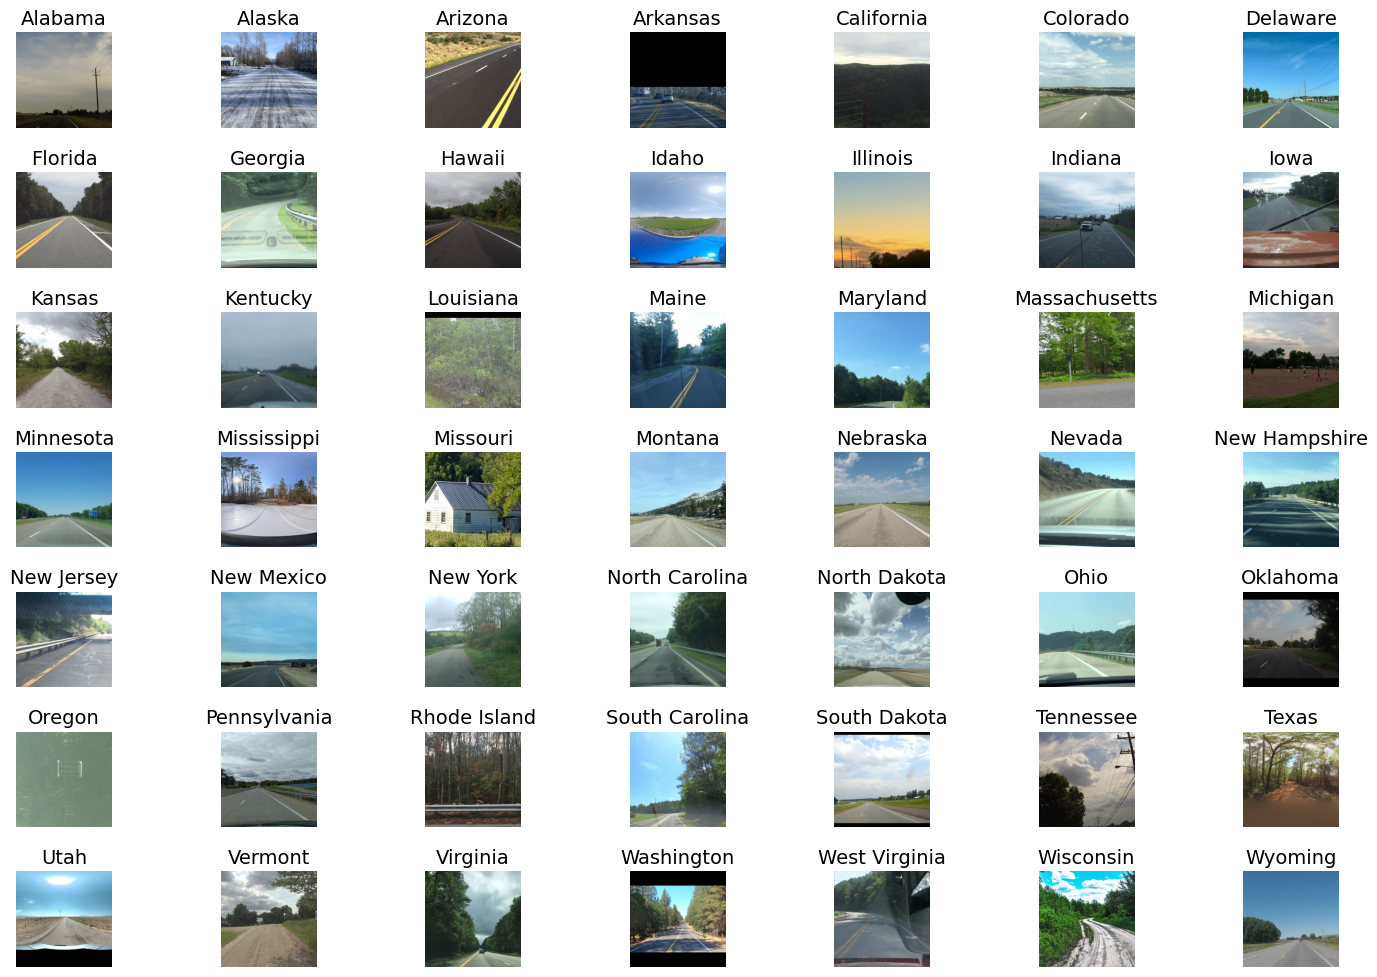

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
for i, (label_idx, img_tensor) in enumerate(sample_flowers):
    plt.subplot(7, 7, i + 1)

    img_np = img_tensor.permute(1, 2, 0).numpy()

    plt.imshow(img_np)
    plt.title(class_names[label_idx])
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
model.classifier

Sequential(
  (0): LayerNorm2d((1024,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=1024, out_features=1000, bias=True)
)

In [ ]:
import torch.nn as nn

n_classes = 50
model.classifier[2] = nn.Linear(1024, n_classes).to(device)

In [ ]:
for param in model.parameters():
  param.requires_grad = False

for param in model.classifier.parameters():
  param.requires_grad = True

In [ ]:
pip install torchmetrics


In [ ]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs, scheduler = None):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
        if scheduler is not None:
          scheduler.step()
    return history

In [ ]:
device

device(type='cuda')

In [ ]:

learning_rate = 5e-5

n_epochs = 40
optimizer = torch.optim.AdamW(model.parameters(), learning_rate, weight_decay = 0.05)
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=50).to(device)
history = train(model, optimizer, xentropy, accuracy, train_loader, val_loader, n_epochs)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs = 100, steps_per_epoch = len(train_loader), max_lr = 1e-2)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
model_path = '/content/drive/MyDrive/geoguessr3.pt'

torch.save(model.state_dict(), model_path)